In [1]:
#### Figure 3a is just the extractor output directly ####

In [3]:
# need to collect all of the signatures 


# lets do TCGA first 
import pandas as pd

tcga_sigs = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/TCGA/results/SBS288/Suggested_Solution/SBS288_De-Novo_Solution/Signatures/SBS288_De-Novo_Signatures.txt',
             index_col=0)
tcga_sigs.index = tcga_sigs.index.str.split(':').str[-1]
tcga_sigs = tcga_sigs.groupby(tcga_sigs.index).sum()


# SWEDISH 
swedish_sigs = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/Swedish_data/results/SBS288/Suggested_Solution/SBS288_De-Novo_Solution/Signatures/SBS288_De-Novo_Signatures.txt',
             index_col=0)


swedish_sigs.index = swedish_sigs.index.str.split(':').str[-1]
swedish_sigs = swedish_sigs.groupby(swedish_sigs.index).sum()


# and now we need to do cosine similarity to the original SBS288D 

denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)
denovos.index = denovos.index.str.split(':').str[-1]
denovos = denovos.groupby(denovos.index).sum()



SBS288D_OG = denovos.loc[:,'SBS288D']
SBS288D_OG.name = 'MUTOGRAPHS_SBS_D'

In [4]:
SBS288B_OG = denovos.loc[:,'SBS288B']
SBS288B_OG.name = 'MUTOGRAPHS_SBS18^'

In [5]:
# lets do the cosine similarities 
# we can do it for the SBS18* sig and SBS288D

tcga_sbs18 = tcga_sigs.loc[:,'SBS288C']
tcga_sbs18.name = 'TCGA_SBS18^'

tcga_sbs288D = tcga_sigs.loc[:,'SBS288D']
tcga_sbs288D.name = 'TCGA_SBS_D'

In [6]:
# swedish next 

SWEDISH_sbs18 = swedish_sigs.loc[:,'SBS288B']
SWEDISH_sbs18.name = 'SWEDISH_SBS18^'

SWEDISH_sbs288D = swedish_sigs.loc[:,'SBS288E']
SWEDISH_sbs288D.name = 'SWEDISH_SBS_D'

In [8]:
# GEL 


GEL_sigs = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/TCGA_SWEDISH_SBS96_sigs/SBS96_De-Novo_Signatures_GEL.txt',
                        index_col=0)

GEL_sbs18 = GEL_sigs.loc[:,'SBS96B']
GEL_sbs18.name = 'GEL_SBS18^'

GEL_sbs288D = GEL_sigs.loc[:,'SBS96F']
GEL_sbs288D.name = 'GEL_SBS_D'

In [9]:
all_together = pd.concat([SBS288B_OG,tcga_sbs18,SWEDISH_sbs18,GEL_sbs18,
          SBS288D_OG,tcga_sbs288D,SWEDISH_sbs288D,GEL_sbs288D],axis=1)

In [11]:
import seaborn as sns
from matplotlib import pyplot as plt

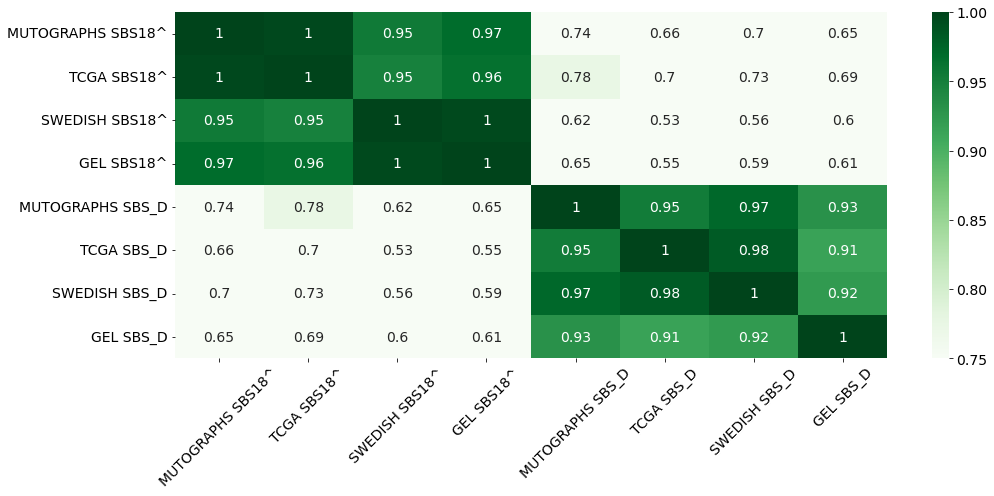

In [12]:
from sklearn.metrics.pairwise import cosine_similarity


fig,ax = plt.subplots(figsize=(15,7))

cs_all_together = pd.DataFrame(cosine_similarity(all_together.T),
                              index = all_together.columns,
                              columns = all_together.columns)


cs_all_together.index = cs_all_together.index.str.replace('_SBS', ' SBS')
cs_all_together.columns = cs_all_together.columns.str.replace('_SBS', ' SBS')

sns.heatmap(cs_all_together,
           cmap='Greens',annot=True,annot_kws={'size': 14},vmin=.75)


for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                     ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(14)
        
plt.xticks(rotation=45)
# plt.yticks(rotation=45)

cbar = ax.collections[0].colorbar
# here set the labelsize by 20
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
# plt.savefig('TCGA_SWEDISH_SBS96_sigs/cosine_similarity_v2.png',
#            dpi=300)